In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime,timedelta
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from scipy.stats import norm
from scipy.special import gamma




# Option pricing in Heston model: illustrations for chapter 7 of lecture notes "Pricing and hedging of financial derivatives"

$$
C(K) = C^{BS}(S_0,K,T,\Sigma) + \frac{S_0}{2\pi}
\int_{-\infty}^{+\infty} e^{-iv k} \frac{\Phi_T(v-i)-\Phi^{\Sigma}_T(v-i)}{iv(1+iv)}dv,
$$
where $k=\log{Ke^{-rT}\over S_0}$, $\Phi_T(u) = \mathbb E[e^{iuX_T}]$ and $\Phi^\Sigma_T$ is the
characteristic function of log-price in the Black-Scholes model with volatility $\Sigma$.

Option prices can be thus computed by evaluating numerically the inverse Fourier transform:
$$z_T(k)=\frac{1}{2\pi}\int_{-\infty}^{+\infty} e^{-ivk} \zeta_T(v)dv
$$This integral can be efficiently computed using the Fast Fourier transform algorithm, which allows to compute $F_0,\ldots,F_{N-1}$, given by,
\begin{eqnarray}  
F_n = \sum_{k=0}^{N-1}f_k e^{-2\pi i n
k/N},\quad n=0\ldots N-1,\notag
\end{eqnarray}  
using only $O(N\ln N)$ operations.

To approximate option prices, we truncate and discretize the integral:
$$\frac{1}{2\pi}\int_{-\infty}^\infty e^{-ivk}\zeta_T(v)dv = \frac{1}{2\pi}\int_{-A/2}^{A/2}e^{-ivk}\zeta_T(v)dv + \varepsilon_T = \frac{A}{2\pi N} \sum_{m=0}^{N-1}w_m \zeta_T(v_m)e^{-ikv_m} + \varepsilon_T+\varepsilon_D,
$$where $\varepsilon_T$ is the truncation error, $\varepsilon_D$ is the discretization error, $v_m = -A/2 + m\Delta$, $\Delta
= A/(N-1)$ is the discretization step and $w_m$ are weights,
corresponding to the chosen integration rule (for instance, for
the trapezoidal rule $w_0 = w_{N-1}=1/2$ and all other weights are equal
to 1).

Setting $k_n = k_0 + \frac{2\pi n}{N\Delta}$,  the
sum in the last term becomes a discrete Fourier transform:
$$\frac{A}{2\pi N}e^{ik_nA/2}\sum_{m=0}^{N-1} w_m e^{-ik_0 v_m} f(k_m)e^{-2\pi i
nm/N}
$$
The FFT algorithm allows to compute $z_T$ and therefore option prices for the log strikes $k_n = k_0 + \frac{2\pi n}{N\Delta}$. The log strikes are thus equidistant with the step $d$ satisfying
$$d\Delta = \frac{2\pi}{N}.\notag
$$Typically, $k_0$ is chosen so that the grid is centered around the money, $\Delta$ is fixed to keep the discretization error low, and $N$ is adjusted to keep the truncation error low and have a sufficiently small step between strikes (increasing $N$ reduces the truncation error and the distance between consecutive strikes at the same time).



In [ ]:
def fprice(param,S0,strikes,matu,rate=0,Sigma=0.2,q=0.005,M=4096):
    cf = fhestoncf;
    pr, st, h, cutoff = fourierprice(S0,q,M,matu,rate,Sigma,param,cf)
    return np.interp(strikes,st,np.real(pr))

def bsprice(S,K,T,r,v):
    d1 = (np.log(S/K)+(r+v*v/2.)*T)/(v*np.sqrt(T))
    d2 = d1-v*np.sqrt(T)
    return S*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)

def volimp(s,k,t,r,c):
  #  pdb.set_trace()
    if((c <= max(s-k*np.exp(-r*t), 0)) or (c>=s)) :
        return float('nan')
    a=0.
    b = 1.
    fb = bsprice(s, k, t, r, b)
    for i in range(10):
        if(c<=fb):
            break
        a= b
        b=b*2.0
        fb = bsprice(s,k,t,r,b)
    if(i >= 10):
        return float('nan')
    for j in range(30+i):
        fb = bsprice(s,k,t,r,(a+b)/2.)
        if(fb > c) :
            b = (a+b)/2.
        else:
            a= (a+b)/2.
    return  (a+b)/2.

def fourierprice(S0,q,M,T,r,Sigma,param,cf):
    k0 = -q*M/2;
    # [prices, strikes, h, cutoff] = cfprice(k0,q,M,T,r,cf,P1,P2,...)
    # Compute call option prices when the characteristic function of the
    # discounted log stock price is known
    # q - log-strike step
    # k0 - smallest log strike
    # M - number of log-strikes
    # T - maturity
    # r - interest rate
    # Sigma - volatility of the auxiliary BS model
    # cf - handle to the characteristic function
    # P1, P2, ... additional parameters to be passed
    # directly to the characteristic function
    # The characteristic function must accept u as vector argument
    # It will be called with cf(u,T,P1,P2,...)
    # one can take for example q = 0.005; M = 4096; Sigma=0.2; k0 = -0.005*2048
    # k0 = -q*M/2;
    h = 2.*np.pi/M/q; # step in dual space
    u = h*np.linspace(-(M-1.)/2.,(M-1.)/2.,M)  # grid in dual space
    fc = cf(u-1j,T,param)*np.exp(-1j*(u-1j)*np.log(cf(-1j*np.ones(1),T,param)))
    dzeta = np.exp(1j*u*r*T)*(fc-np.exp(-Sigma*Sigma*T/2*(u*u-1j*u)))/(1j*u*(1+1j*u))
    b = np.exp(-1j*k0*h*np.linspace(0.,M-1.,M))
    b[0] = b[0]/2 # trapezoidal rule weights
    b[-1] = b[-1]/2
    ft = np.fft.fft(dzeta*b)
    z = h/2/np.pi*ft*np.exp(1j*h*(M-1)/2*(k0+q*np.linspace(0.,M-1.,M)))
    strikes = S0*np.exp(k0+q*np.linspace(0,M-1,M))
    prices = S0*z+bsprice(S0,strikes,T,r,Sigma)
    cutoff = M/2*h
    return prices, strikes, h, cutoff



def fhestoncf(u,t,param):
    rho = param[0] # correlation
    v0 = param[1] # sigma_0^2
    sigma = param[2] # volatility of volatility
    xi = param[3] # mean reversion coefficient
    eta = param[4] # mean volatility
    gamm = np.sqrt(sigma*sigma*(u*u+1j*u)+(xi-1j*rho*sigma*u)*(xi-1j*rho*sigma*u))
    c1 = xi*eta*t*(xi-1j*rho*sigma*u)/sigma/sigma
    c2 = -v0*(u*u+1j*u)/(gamm/np.tanh(gamm*t/2)+xi-1j*rho*sigma*u)
    c3 = (gamm*t/2+np.log((1+np.exp(-gamm*t))/2+(xi-1j*rho*sigma*u)/gamm*(1-np.exp(-gamm*t))/2))*(2*xi*eta/sigma/sigma)
    cf = np.exp(c1+c2-c3)
    return cf

In [ ]:
rho  = 0.5
v0 = 0.04
sigma = .5
xi = 3.0
eta = 0.04
S0 = 100.
matu = 0.5
strikes = np.linspace(50,200,100)
prices = fprice([rho,v0,sigma,xi,eta],S0,strikes,matu)

Text(0.5, 1.0, 'Implied volatility')

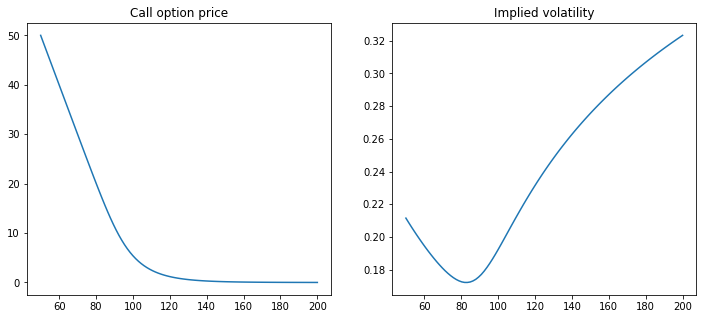

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(strikes,prices)
plt.title('Call option price')
ivol = np.zeros(len(strikes))
for i in range(len(strikes)):
  ivol[i] = volimp(S0,strikes[i],matu,0.,prices[i])
plt.subplot(122)
plt.plot(strikes,ivol)
plt.title('Implied volatility')